# Code in Homework 2 for MSDM 5054

Author: LAN, Tianwei 藍天蔚<br>
ID: 21230969<br>
Email: tlanaa@connect.ust.hk

# Problem 2

Used generative AI to help generate code for using LR, LDA, and QDA model fitting APIs, as well as optimize ROC curve drawing code.

# (1) LR with all predictors (with ROC curve)

In [7]:
# Check multicollinearity (VIF)
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load and clean data
df = pd.read_csv("BreastCancer_train.csv")
df = df.dropna()
y = (df['Class'] == 'malignant').astype(int).reset_index(drop=True)
X = df.drop(columns=['Id', 'Class'])
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factors (VIF):")
print(vif_data.round(2))

Variance Inflation Factors (VIF):
          Variable    VIF
0       Cell.shape  13.33
1        Cell.size  13.26
2      Bl.cromatin   8.01
3     Epith.c.size   6.42
4     Cl.thickness   5.33
5      Bare.nuclei   5.29
6  Normal.nucleoli   5.20
7    Marg.adhesion   4.80
8          Mitoses   2.70


In [8]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = X.drop(columns=['Cell.size'])
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_const = sm.add_constant(X_scaled)
logit_model = sm.Logit(y, X_const).fit(disp=0)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  392
Model:                          Logit   Df Residuals:                      383
Method:                           MLE   Df Model:                            8
Date:                Thu, 02 Oct 2025   Pseudo R-squ.:                  0.8918
Time:                        16:32:34   Log-Likelihood:                -27.377
converged:                       True   LL-Null:                       -253.05
Covariance Type:            nonrobust   LLR p-value:                 1.906e-92
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.3969      0.492     -2.837      0.005      -2.362      -0.432
Cl.thickness        1.1198      0.606      1.848      0.065      -0.068       2.307
Cell.shape          0.9814      

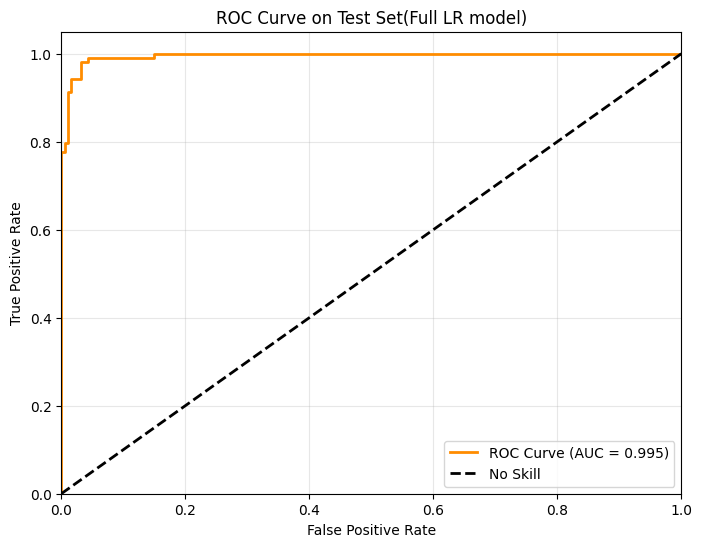

Test Set AUC: 0.9951


In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Evaluate on test set and plot ROC curve
df_test = pd.read_csv("BreastCancer_test.csv").dropna()
y_test = (df_test['Class'] == 'malignant').astype(int).reset_index(drop=True)

# Standardize
X_test = df_test[X.columns]
X_test_scaled = (X_test - X.mean()) / X.std()
X_test_const = sm.add_constant(pd.DataFrame(X_test_scaled, columns=X.columns))

# Predict and evaluate
y_pred_proba = logit_model.predict(X_test_const)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set(Full LR model)'); plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

print(f"Test Set AUC: {roc_auc:.4f}")

# (2) LR using specified predictors (with ROC curve)

In [10]:
# Check multicollinearity (VIF)
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load and clean data
df = pd.read_csv("BreastCancer_train.csv")
df = df.dropna()
y = (df['Class'] == 'malignant').astype(int).reset_index(drop=True)
X = df[['Cl.thickness', 'Cell.shape', 'Marg.adhesion', 'Bare.nuclei', 'Bl.cromatin']]
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("Variance Inflation Factors (VIF):")
print(vif_data.round(2))

Variance Inflation Factors (VIF):
        Variable   VIF
0    Bl.cromatin  6.80
1     Cell.shape  6.68
2    Bare.nuclei  5.21
3   Cl.thickness  4.88
4  Marg.adhesion  4.43


In [11]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_const = sm.add_constant(X_scaled)
logit_model = sm.Logit(y, X_const).fit(disp=0)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  392
Model:                          Logit   Df Residuals:                      386
Method:                           MLE   Df Model:                            5
Date:                Thu, 02 Oct 2025   Pseudo R-squ.:                  0.8788
Time:                        16:33:12   Log-Likelihood:                -30.681
converged:                       True   LL-Null:                       -253.05
Covariance Type:            nonrobust   LLR p-value:                 6.717e-94
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.3602      0.392     -3.470      0.001      -2.128      -0.592
Cl.thickness      1.3730      0.546      2.513      0.012       0.302       2.444
Cell.shape        1.4800      0.603     

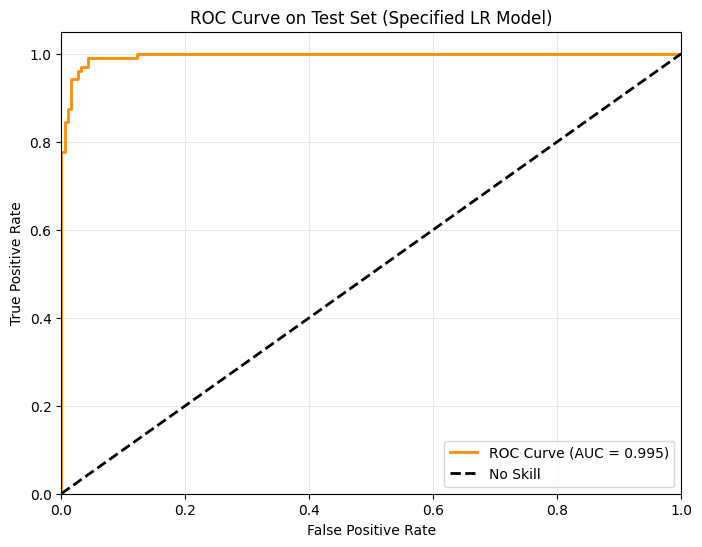

Test Set AUC: 0.9954


In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Evaluate on test set and plot ROC curve
df_test = pd.read_csv("BreastCancer_test.csv").dropna()
y_test = (df_test['Class'] == 'malignant').astype(int).reset_index(drop=True)

# Standardize
X_test = df_test[X.columns]
X_test_scaled = (X_test - X.mean()) / X.std()
X_test_const = sm.add_constant(pd.DataFrame(X_test_scaled, columns=X.columns))

# Predict and evaluate
y_pred_proba = logit_model.predict(X_test_const)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set (Specified LR Model)'); plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

print(f"Test Set AUC: {roc_auc:.4f}")

# (3) LDA using all predictors (with ROC curve)

In [ ]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Clean and set data
df = pd.read_csv("BreastCancer_train.csv")
df = df.dropna()
y = (df['Class'] == 'malignant').astype(int).reset_index(drop=True)
X = df.drop(columns=['Id', 'Class'])
X = X.apply(pd.to_numeric, errors='coerce')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# fit LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

# print summary
print("LDA Model Summary:")
print(f"- Number of classes: {lda.classes_}")
print(f"- Number of features: {lda.n_features_in_}")
print(f"- Explained variance ratio (for each component): {lda.explained_variance_ratio_}")
coef_df = pd.DataFrame(lda.coef_, columns=X.columns, index=['LDA Coefficient'])
print()
print(coef_df.T.sort_values('LDA Coefficient', key=abs, ascending=False))

LDA Model Summary:
- Number of classes: [0 1]
- Number of features: 9
- Explained variance ratio (for each component): [1.]

                 LDA Coefficient
Bare.nuclei             4.623214
Cl.thickness            2.202706
Cell.shape              1.729798
Normal.nucleoli         1.629445
Bl.cromatin             1.570730
Epith.c.size            1.460001
Marg.adhesion           1.280402
Cell.size               1.210451
Mitoses                -0.255648


c:\Users\86137\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


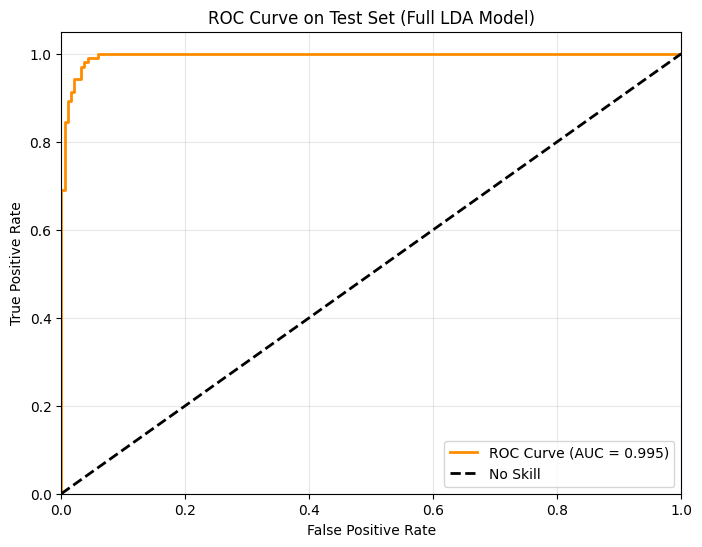

Test Set AUC: 0.9955


In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Load and prepare test set
df_test = pd.read_csv("BreastCancer_test.csv").dropna()
y_test = (df_test['Class'] == 'malignant').astype(int).reset_index(drop=True)
X_test = df_test[X.columns]

# Standardize test set using the SAME scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# Predict probability of malignant class (class 1)
y_pred_proba = lda.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set (Full LDA Model)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Test Set AUC: {roc_auc:.4f}")

# (4) LDA using specified predictors (with ROC curve)

In [13]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Clean and set data
df = pd.read_csv("BreastCancer_train.csv")
df = df.dropna()
y = (df['Class'] == 'malignant').astype(int).reset_index(drop=True)
X = df[['Cl.thickness', 'Cell.shape', 'Marg.adhesion', 'Bare.nuclei', 'Bl.cromatin']]
X = X.apply(pd.to_numeric, errors='coerce')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# fit LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

# print summary
print("LDA Model Summary:")
print(f"- Number of classes: {lda.classes_}")
print(f"- Number of features: {lda.n_features_in_}")
print(f"- Explained variance ratio (for each component): {lda.explained_variance_ratio_}")
coef_df = pd.DataFrame(lda.coef_, columns=X.columns, index=['LDA Coefficient'])
print()
print(coef_df.T.sort_values('LDA Coefficient', key=abs, ascending=False))

LDA Model Summary:
- Number of classes: [0 1]
- Number of features: 5
- Explained variance ratio (for each component): [1.]

               LDA Coefficient
Bare.nuclei           4.229657
Cell.shape            3.382348
Bl.cromatin           2.341092
Cl.thickness          2.174089
Marg.adhesion         1.554266


c:\Users\86137\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


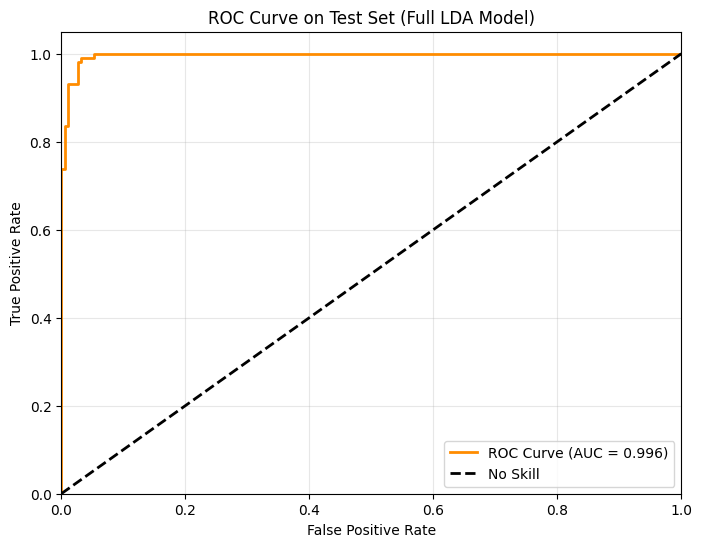

Test Set AUC: 0.9963


In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Load and prepare test set
df_test = pd.read_csv("BreastCancer_test.csv").dropna()
y_test = (df_test['Class'] == 'malignant').astype(int).reset_index(drop=True)
X_test = df_test[X.columns]

# Standardize test set using the SAME scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# Predict probability of malignant class (class 1)
y_pred_proba = lda.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set (Full LDA Model)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Test Set AUC: {roc_auc:.4f}")

# (5) QDA using full predictors (with ROC curve)

In [15]:
import pandas as pd
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

# Load and prepare training data
df = pd.read_csv("BreastCancer_train.csv")
df = df.dropna()
y = (df['Class'] == 'malignant').astype(int).reset_index(drop=True)
X = df.drop(columns=['Id', 'Class'])
X = X.apply(pd.to_numeric, errors='coerce')

# Standardize features (QDA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Fit QDA model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_scaled, y)

QuadraticDiscriminantAnalysis()

c:\Users\86137\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


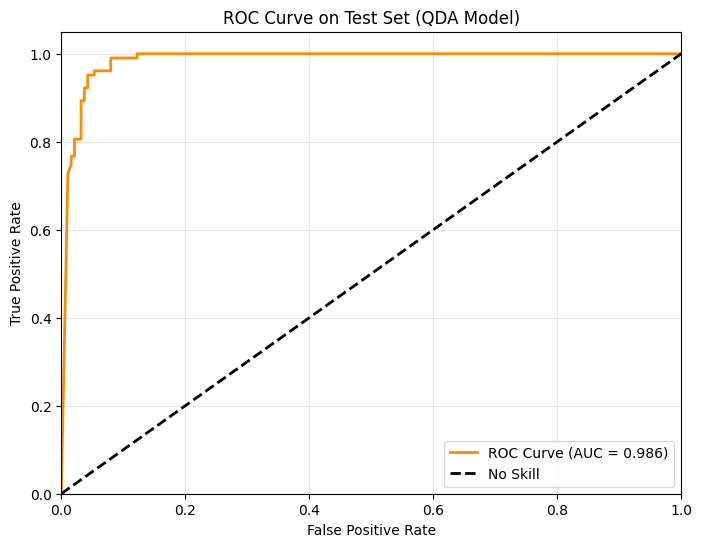

Test Set AUC: 0.9856


In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Load and prepare test set
df_test = pd.read_csv("BreastCancer_test.csv").dropna()
y_test = (df_test['Class'] == 'malignant').astype(int).reset_index(drop=True)
X_test = df_test[X.columns]

# Standardize
X_test_scaled = scaler.transform(X_test)

# Predict probability of malignant class (class 1)
y_pred_proba = qda.predict_proba(X_test_scaled)[:, 1]

# Compute ROC and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set (QDA Model)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Test Set AUC: {roc_auc:.4f}")

# Problem 3

## (1) LOOCV: relation between polynomial degrees and CV errors

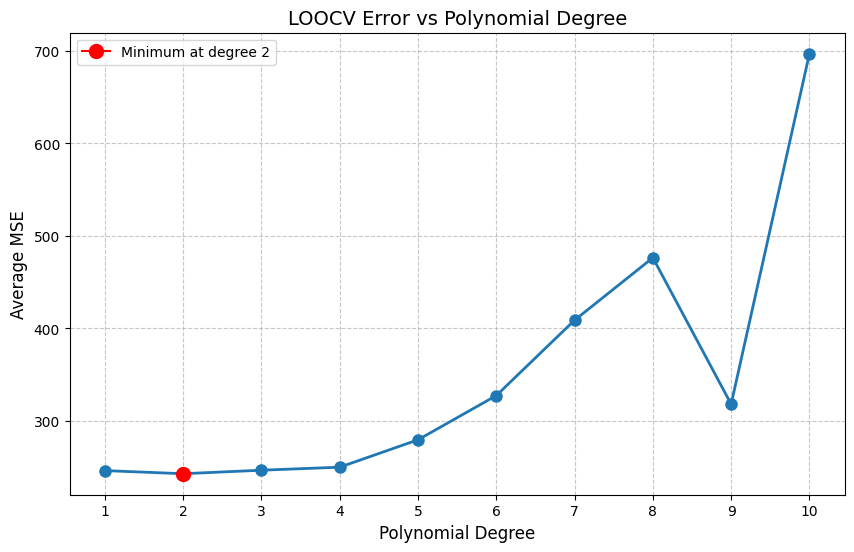

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Cars.csv')
speed = df['speed'].values
dist = df['dist'].values
degrees = range(1, 11)
cv_errors = []

for degree in degrees:
    mse_scores = []
    for i in range(len(speed)):             # Every data used once as test point
        train_speed = np.delete(speed, i)
        train_dist = np.delete(dist, i)
        test_speed = speed[i]
        test_dist = dist[i]
        
        # Fit model and predict
        coeffs = np.polyfit(train_speed, train_dist, degree)
        poly = np.poly1d(coeffs)
        pred_dist = poly(test_speed)
        
        # Compute MSE
        mse = (test_dist - pred_dist) ** 2
        mse_scores.append(mse)
    avg_mse = np.mean(mse_scores)
    cv_errors.append(avg_mse)

min_error = min(cv_errors)
optimal_degree = degrees[cv_errors.index(min_error)]

# Plot the CV errors against the polynomial degrees
plt.figure(figsize=(10, 6))
plt.plot(degrees, cv_errors, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.plot(optimal_degree, min_error, marker='o', color='red', markersize=10, label=f'Minimum at degree {optimal_degree}')
plt.title('LOOCV Error vs Polynomial Degree', fontsize=14)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Average MSE', fontsize=12)
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## (2) 5-Folds CV errors vs. polynomial degrees

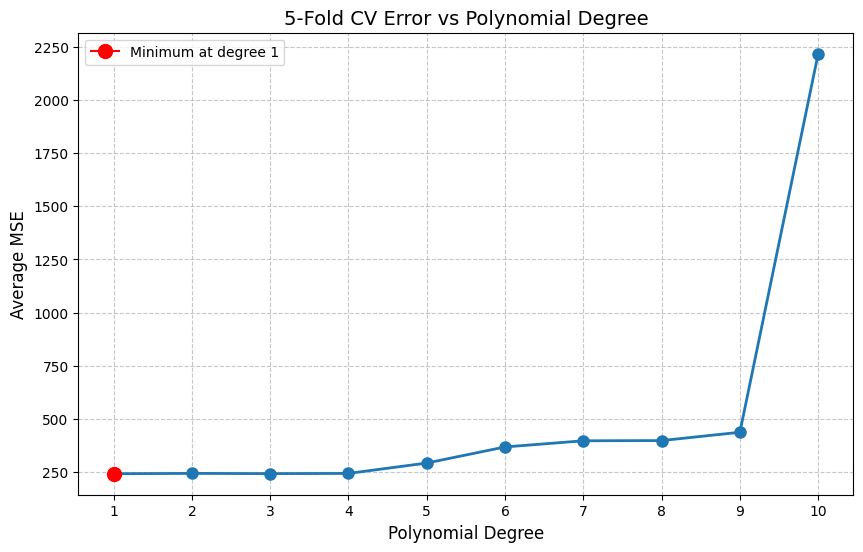

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

df = pd.read_csv('Cars.csv')
speed = df['speed'].values
dist = df['dist'].values
degrees = range(1, 11)
cv_errors = []

# 5-fold CV
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

for degree in degrees:
    mse_scores = []
    for train_index, test_index in kf.split(speed): # test K times
        train_speed = speed[train_index]
        train_dist = dist[train_index]
        test_speed = speed[test_index]
        test_dist = dist[test_index]
        
        # Fit model and predict
        coeffs = np.polyfit(train_speed, train_dist, degree)
        poly = np.poly1d(coeffs)
        pred_dist = poly(test_speed)
        
        # Compute MSE for this fold
        mse = np.mean((test_dist - pred_dist) ** 2)
        mse_scores.append(mse)
    
    avg_mse = np.mean(mse_scores)
    cv_errors.append(avg_mse)

min_error = min(cv_errors)
optimal_degree = degrees[cv_errors.index(min_error)]

# Plot the CV errors against the polynomial degrees
plt.figure(figsize=(10, 6))
plt.plot(degrees, cv_errors, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.plot(optimal_degree, min_error, marker='o', color='red', markersize=10, label=f'Minimum at degree {optimal_degree}')
plt.title('5-Fold CV Error vs Polynomial Degree', fontsize=14)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Average MSE', fontsize=12)
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## (3) KNN-Gaussian bandwidth CV optimization diagram

Used AI to aid using scipy and sklearn

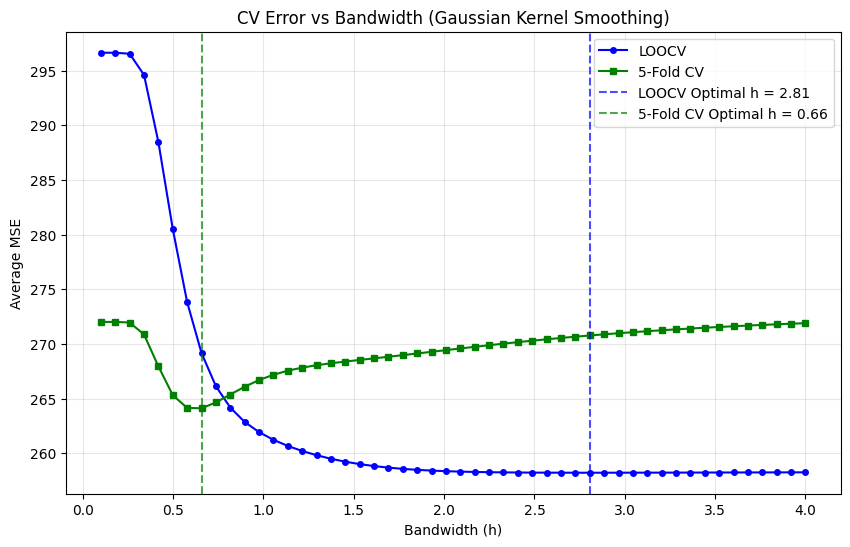

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('Cars.csv')
x = df['speed'].values
y = df['dist'].values
bandwidths = np.linspace(0.1, 4.0, 50)

def gaussian_knn_smooth(x_train, y_train, x_val, k=5, h=1.0):
    x_train = x_train.reshape(-1, 1)
    x_val = x_val.reshape(-1, 1)
    nbrs = NearestNeighbors(n_neighbors=k, algorithm='kd_tree').fit(x_train)
    distances, indices = nbrs.kneighbors(x_val)
    weights = np.exp(-0.5 * (distances / h) ** 2)
    y_neighbors = y_train[indices]
    return np.sum(weights * y_neighbors, axis=1) / np.sum(weights, axis=1)

# LOOCV
loocv_errors = []
for h in bandwidths:
    mse_scores = []
    for i in range(len(x)):
        x_train = np.delete(x, i)
        y_train = np.delete(y, i)
        x_val = x[i:i+1]
        y_val = y[i:i+1]
        y_pred = gaussian_knn_smooth(x_train, y_train, x_val, k=5, h=h)
        mse = np.mean((y_val - y_pred) ** 2)
        mse_scores.append(mse)
    loocv_errors.append(np.mean(mse_scores))

# 5-Fold CV
kfold_errors = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for h in bandwidths:
    mse_scores = []
    for train_idx, val_idx in kf.split(x):
        x_train, y_train = x[train_idx], y[train_idx]
        x_val, y_val = x[val_idx], y[val_idx]
        
        y_pred = gaussian_knn_smooth(x_train, y_train, x_val, k=5, h=h)
        mse = np.mean((y_val - y_pred) ** 2)
        mse_scores.append(mse)
    kfold_errors.append(np.mean(mse_scores))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(bandwidths, loocv_errors, 'b-o', markersize=4, label='LOOCV')
plt.plot(bandwidths, kfold_errors, 'g-s', markersize=4, label='5-Fold CV')

opt_h_loocv = bandwidths[np.argmin(loocv_errors)]
opt_h_kfold = bandwidths[np.argmin(kfold_errors)]

plt.axvline(opt_h_loocv, color='blue', linestyle='--', alpha=0.7, 
           label=f'LOOCV Optimal h = {opt_h_loocv:.2f}')
plt.axvline(opt_h_kfold, color='green', linestyle='--', alpha=0.7, 
           label=f'5-Fold CV Optimal h = {opt_h_kfold:.2f}')

plt.title('CV Error vs Bandwidth (Gaussian Kernel Smoothing)')
plt.xlabel('Bandwidth (h)')
plt.ylabel('Average MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("3_3_CVerror.png")
plt.show()

# Problem 4

## （1）LR

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv('titanic.csv')
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']]
df = df.dropna()

# dummy encoding for P-class and Sex
pclass_dummies = pd.get_dummies(df['Pclass'], prefix='Pclass', drop_first=True)
sex_dummies = pd.get_dummies(df['Sex'], prefix='Sex', drop_first=True)

X = pd.concat([
    df[['Age', 'SibSp', 'Fare']],
    pclass_dummies,
    sex_dummies
], axis=1)
y = df['Survived']
X = sm.add_constant(X)
X = X.astype(float)
logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=False)

# print("=== Logistic Regression Summary ===")
# print(result.summary())

conf_int = result.conf_int()
params = result.params

# Sex_male
sex_male_coef = params['Sex_male']
sex_male_ci_low, sex_male_ci_high = conf_int.loc['Sex_male']

# Pclass_3's coef & CI
pclass_3_coef = params['Pclass_3']
pclass_3_ci_low, pclass_3_ci_high = conf_int.loc['Pclass_3']

print("Coefficient for Sex = male (vs female): {:.4f}".format(sex_male_coef))
print("95% Confidence Interval: [{:.4f}, {:.4f}]".format(sex_male_ci_low, sex_male_ci_high))

print("\nCoefficient for Pclass = 3rd (vs 1st): {:.4f}".format(pclass_3_coef))
print("95% Confidence Interval: [{:.4f}, {:.4f}]".format(pclass_3_ci_low, pclass_3_ci_high))

Coefficient for Sex = male (vs female): -2.6161
95% Confidence Interval: [-3.0383, -2.1939]

Coefficient for Pclass = 3rd (vs 1st): -2.5258
95% Confidence Interval: [-3.1816, -1.8700]


## (2) 1000 bootstraps for same CI

In [15]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('titanic.csv')
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']]
df = df.dropna()

# dummy encoding for P-class and Sex
df_encoded = pd.get_dummies(df, columns=['Pclass', 'Sex'], drop_first=True)
feature_cols = ['Age', 'SibSp', 'Fare', 'Pclass_2', 'Pclass_3', 'Sex_male']
X = df_encoded[feature_cols].values.astype(float)
y = df_encoded['Survived'].values.astype(int)

# fit original model
log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
log_reg.fit(X, y)
coef_dict = dict(zip(feature_cols, log_reg.coef_[0]))

# bootstrap
np.random.seed(42)
n_bootstraps = 1000
n = len(X)
boot_sex = []
boot_pclass3 = []

for _ in range(n_bootstraps):
    idx = np.random.choice(n, size=n, replace=True)
    X_boot, y_boot = X[idx], y[idx]
    try:
        model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
        model.fit(X_boot, y_boot)
        coefs = dict(zip(feature_cols, model.coef_[0]))
        boot_sex.append(coefs['Sex_male'])
        boot_pclass3.append(coefs['Pclass_3'])
    except:
        continue

# compute bootstrap CIs
sex_ci = np.percentile(boot_sex, [2.5, 97.5])
pclass3_ci = np.percentile(boot_pclass3, [2.5, 97.5])

print("Coefficient for Sex = male (vs female): {:.4f}".format(coef_dict['Sex_male']))
print("95% Bootstrap Confidence Interval: [{:.4f}, {:.4f}]".format(sex_ci[0], sex_ci[1]))

print("\nCoefficient for Pclass = 3rd (vs 1st): {:.4f}".format(coef_dict['Pclass_3']))
print("95% Bootstrap Confidence Interval: [{:.4f}, {:.4f}]".format(pclass3_ci[0], pclass3_ci[1]))

Coefficient for Sex = male (vs female): -2.6161
95% Bootstrap Confidence Interval: [-3.0819, -2.2201]

Coefficient for Pclass = 3rd (vs 1st): -2.5257
95% Bootstrap Confidence Interval: [-3.2251, -1.9044]


## (3) Explore the dataset

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic.csv')

print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Overall survival rate:", df['Survived'].mean())

# Survival by sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("Female survival:", survival_by_sex['female'])
print("Male survival:", survival_by_sex['male'])

# Survival by class
survival_by_pclass = df.groupby('Pclass')['Survived'].mean()
print("Survival by Pclass:\n", survival_by_pclass)

# Age stats
print("Mean age:", df['Age'].mean())
print("Age range:", df['Age'].min(), "to", df['Age'].max())

# Fare stats
print("Mean fare:", df['Fare'].mean())

Shape: (891, 12)
Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Overall survival rate: 0.3838383838383838
Female survival: 0.7420382165605095
Male survival: 0.18890814558058924
Survival by Pclass:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Mean age: 29.69911764705882
Age range: 0.42 to 80.0
Mean fare: 32.204207968574636


## (4) Predicting Survival Probability for a Single Passenger with Bootstrap Uncertainty Quantification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# Load data
df = pd.read_csv('titanic.csv')
# print("First passenger (test point):")
# print(df.iloc[0][['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']])

# Separate test point (first row) and training set (rest)
test_point = df.iloc[[0]]
train_df = df.iloc[1:].copy()

# Preprocess training set
train_df = train_df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']].dropna()
train_encoded = pd.get_dummies(train_df, columns=['Pclass', 'Sex'], drop_first=True)
feature_cols = ['Age', 'SibSp', 'Fare', 'Pclass_2', 'Pclass_3', 'Sex_male']
X_train = train_encoded[feature_cols].values.astype(float)
y_train = train_encoded['Survived'].values.astype(int)

# Prepare test point in same format
# ['Age', 'SibSp', 'Fare', 'Pclass_2', 'Pclass_3', 'Sex_male']
X_test = [[22.,1.,7.25,0.,1.,1.]]

# Fit model on full training set and get point prediction
log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
log_reg.fit(X_train, y_train)
point_pred = log_reg.predict_proba(X_test)[0, 1]

# Bootstrap for prediction interval
np.random.seed(42)
n_bootstraps = 1000
n = len(X_train)
boot_preds = []

for _ in range(n_bootstraps):
    idx = np.random.choice(n, size=n, replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]
    try:
        model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
        model.fit(X_boot, y_boot)
        pred = model.predict_proba(X_test)[0, 1]
        boot_preds.append(pred)
    except:
        continue

# Compute 95% prediction interval
boot_preds = np.array(boot_preds)
pred_interval = np.percentile(boot_preds, [2.5, 97.5])

print(f"Predicted survival probability for test point: {point_pred:.4f}")
print(f"95% Bootstrap Prediction Interval: [{pred_interval[0]:.4f}, {pred_interval[1]:.4f}]")

Predicted survival probability for test point: 0.0896
95% Bootstrap Prediction Interval: [0.0578, 0.1263]


## (5) Predicting Survival Probability for a Single Passenger Using QDA with Bootstrap Uncertainty Quantification

In [20]:
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Load data
df = pd.read_csv('titanic.csv')

# Separate test point (first row) and training set (rest)
test_point = df.iloc[[0]]
train_df = df.iloc[1:].copy()

# Preprocess training set
train_df = train_df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']].dropna()
train_encoded = pd.get_dummies(train_df, columns=['Pclass', 'Sex'], drop_first=True)
feature_cols = ['Age', 'SibSp', 'Fare', 'Pclass_2', 'Pclass_3', 'Sex_male']
X_train = train_encoded[feature_cols].values.astype(float)
y_train = train_encoded['Survived'].values.astype(int)

# Prepare test point in same format
test_full = pd.concat([test_point, train_df.iloc[:0]], ignore_index=True)
test_full = test_full[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare']]
test_encoded = pd.get_dummies(test_full, columns=['Pclass', 'Sex'], drop_first=True)
for col in feature_cols:
    if col not in test_encoded.columns:
        test_encoded[col] = 0
X_test = test_encoded[feature_cols].values.astype(float)

# Fit QDA on full training set and get point prediction
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
point_pred = qda.predict_proba(X_test)[0, 1]

# Bootstrap for prediction interval
np.random.seed(42)
n_bootstraps = 1000
n = len(X_train)
boot_preds = []

for _ in range(n_bootstraps):
    idx = np.random.choice(n, size=n, replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]
    try:
        model = QuadraticDiscriminantAnalysis()
        model.fit(X_boot, y_boot)
        pred = model.predict_proba(X_test)[0, 1]
        boot_preds.append(pred)
    except:
        continue

# Compute 95% prediction interval
boot_preds = np.array(boot_preds)
pred_interval = np.percentile(boot_preds, [2.5, 97.5])

print(f"QDA predicted survival probability for test point: {point_pred:.4f}")
print(f"95% Bootstrap Prediction Interval: [{pred_interval[0]:.4f}, {pred_interval[1]:.4f}]")

QDA predicted survival probability for test point: 0.9996
95% Bootstrap Prediction Interval: [0.9966, 1.0000]
